In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [2]:
pokemon = Table.read_table('data/pokemon.csv')
pokemon = pokemon.where('generation', 1).select('name', 'type1', 'hp')
pokemon

name,type1,hp
Bulbasaur,grass,45
Ivysaur,grass,60
Venusaur,grass,80
Charmander,fire,39
Charmeleon,fire,58
Charizard,fire,78
Squirtle,water,44
Wartortle,water,59
Blastoise,water,79
Caterpie,bug,45


In [3]:
pokemon.take(5)

name,type1,hp
Charizard,fire,78


In [5]:
pokemon.take(make_array(0, 3, 6, 24)) # deterministic sample

name,type1,hp
Bulbasaur,grass,45
Charmander,fire,39
Squirtle,water,44
Pikachu,electric,35


In [8]:
first_10 = pokemon.take(np.arange(10))
first_10

name,type1,hp
Bulbasaur,grass,45
Ivysaur,grass,60
Venusaur,grass,80
Charmander,fire,39
Charmeleon,fire,58
Charizard,fire,78
Squirtle,water,44
Wartortle,water,59
Blastoise,water,79
Caterpie,bug,45


In [10]:
np.random.choice(first_10.column(0), 7) # with replacement

array(['Wartortle', 'Venusaur', 'Blastoise', 'Charizard', 'Charizard',
       'Ivysaur', 'Caterpie'],
      dtype='<U12')

In [13]:
np.random.choice(first_10.column(0), 7, replace=False)

array(['Bulbasaur', 'Caterpie', 'Wartortle', 'Venusaur', 'Blastoise',
       'Ivysaur', 'Squirtle'],
      dtype='<U12')

In [14]:
np.random.choice(first_10.column(0), 11)

array(['Venusaur', 'Bulbasaur', 'Charmeleon', 'Wartortle', 'Bulbasaur',
       'Squirtle', 'Bulbasaur', 'Ivysaur', 'Wartortle', 'Caterpie',
       'Charizard'],
      dtype='<U12')

In [15]:
np.random.choice(first_10.column(0), 11, replace=False)

ValueError: Cannot take a larger sample than population when 'replace=False'

In [17]:
first_10.sample(7)

name,type1,hp
Caterpie,bug,45
Charizard,fire,78
Ivysaur,grass,60
Ivysaur,grass,60
Wartortle,water,59
Charizard,fire,78
Charizard,fire,78


In [19]:
first_10.sample(7, with_replacement=False)

name,type1,hp
Ivysaur,grass,60
Blastoise,water,79
Squirtle,water,44
Wartortle,water,59
Venusaur,grass,80
Caterpie,bug,45
Charizard,fire,78


# Distributions

In [21]:
die = Table().with_column('Face', np.arange(1, 7, 1))
die

Face
1
2
3
4
5
6


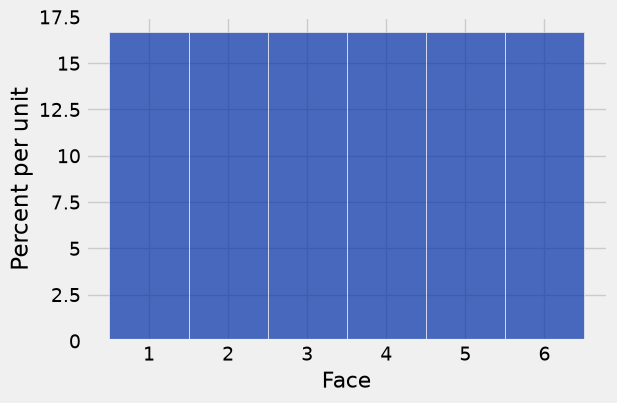

In [23]:
die.hist(bins=np.arange(0.5, 6.6, 1)) # uniform distribution: every value is 1/6

In [24]:
1/6

0.16666666666666666

In [27]:
die.sample(10)

Face
1
5
1
1
2
4
6
3
2
5


In [32]:
np.average(die.sample(10).column(0))

2.7000000000000002

In [36]:
np.average(die.sample(100).column(0))

3.4500000000000002

In [37]:
np.average(die.sample(1000).column(0))

3.4780000000000002

In [38]:
np.average(die.sample(1000000).column(0))

3.4985200000000001

In [39]:
np.average(die.column(0)) # the theoretical value!

3.5

# Law of Large Numbers / Law of Averages

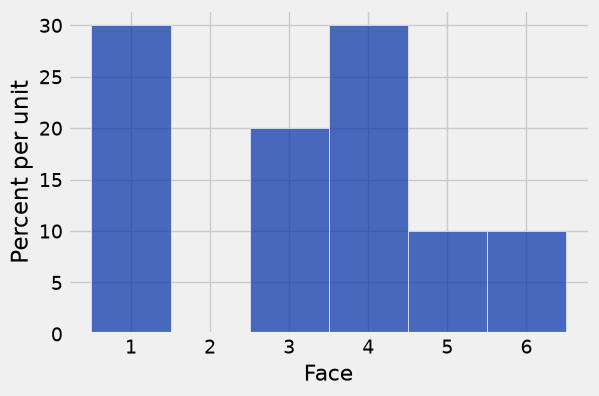

In [42]:
die.sample(10).hist(bins=np.arange(0.5, 6.6, 1)) # an empirical distribution!

In [43]:
def empirical_hist_die(n):
    die.sample(n).hist(bins=np.arange(0.5, 6.6, 1))

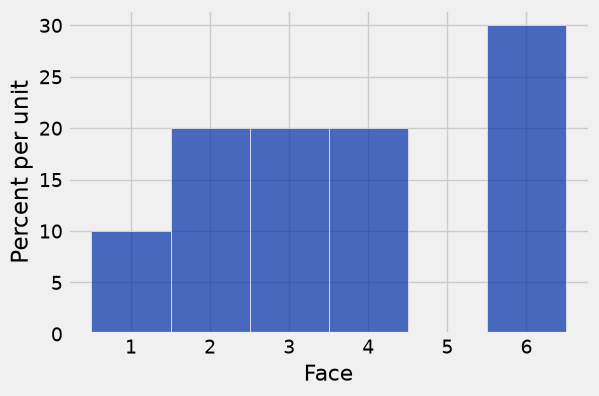

In [44]:
empirical_hist_die(10)

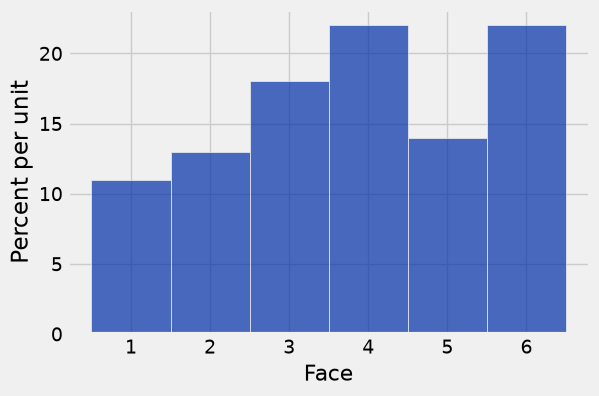

In [45]:
empirical_hist_die(100)

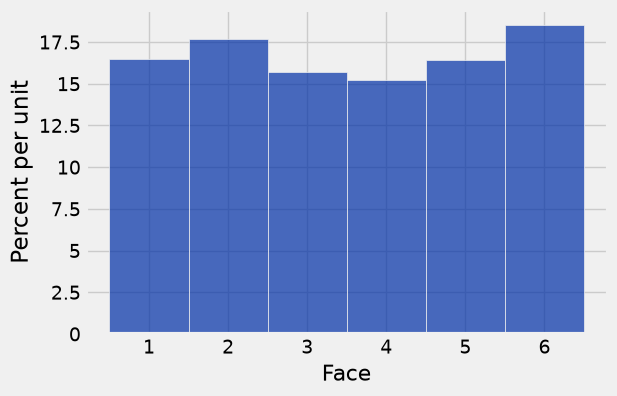

In [46]:
empirical_hist_die(1000)

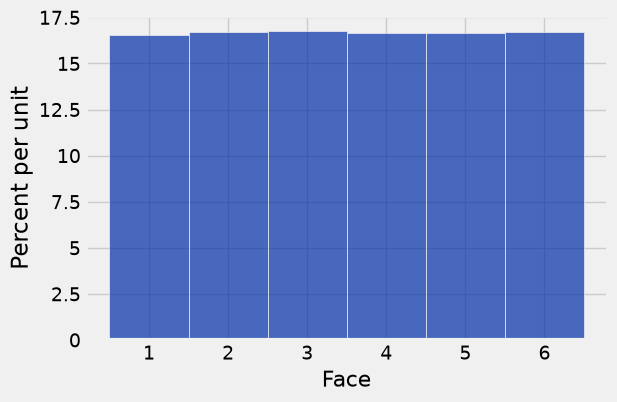

In [47]:
empirical_hist_die(1000000)

In [48]:
trips = Table.read_table('data/202506-baywheels-tripdata.csv.zip')
trips

rideable_type,started_at,ended_at,duration,start_station_name,end_station_name,member_casual
classic_bike,2025-06-30 09:07:18.625,2025-06-30 09:16:12.722,534.097,62nd St at Claremont Ave,Telegraph Ave at 49th St,member
electric_bike,2025-06-03 13:07:55.313,2025-06-03 13:16:31.166,515.853,MLK Jr Way at University Ave,Fulton St at Ashby Ave,member
classic_bike,2025-06-23 09:13:34.202,2025-06-23 09:21:50.823,496.621,Precita Park,Harrison St at 20th St,casual
classic_bike,2025-06-16 13:24:02.794,2025-06-16 13:34:30.657,627.863,San Pablo Park,San Pablo Park,member
electric_bike,2025-06-04 06:47:59.506,2025-06-04 07:00:28.534,749.028,Broadway at 40th St,Bay Street Plaza,casual
electric_bike,2025-06-03 17:38:46.966,2025-06-03 17:47:45.805,538.839,Masonic Ave at Turk St,Masonic Ave at Turk St,casual
electric_bike,2025-06-03 21:41:02.433,2025-06-03 21:47:29.827,387.394,Masonic Ave at Turk St,Haight St at Lyon St,casual
electric_bike,2025-06-15 00:26:46.204,2025-06-15 00:41:38.997,892.793,Masonic Ave at Turk St,34th Ave at Balboa St,member
electric_bike,2025-06-03 21:40:42.205,2025-06-03 21:48:15.143,452.938,Masonic Ave at Turk St,Broderick St at Oak St,casual
classic_bike,2025-06-28 16:01:15.655,2025-06-28 16:07:09.931,354.276,23rd St at San Bruno Ave,20th St at Bryant St,member


In [49]:
trips.column('duration').min(), trips.column('duration').max(), trips.column('duration').mean()

(0.084000000000000005, 89680.506999999998, 755.58857930525824)

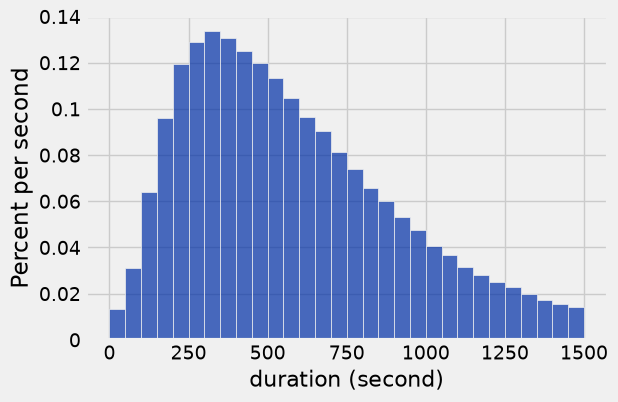

In [52]:
trips.hist('duration', bins=np.arange(0, 1501, 50), unit='second')

In [53]:
# the trips table is the data for the entire population!
# let's prove that the law of large numbers works for samples

In [54]:
def empirical_hist_duration(n):
    trips.sample(n).hist('duration', bins=np.arange(0, 1501, 50), unit='second')

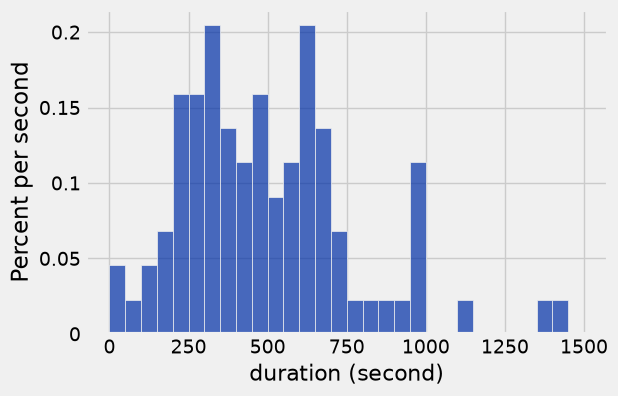

In [55]:
empirical_hist_duration(100)

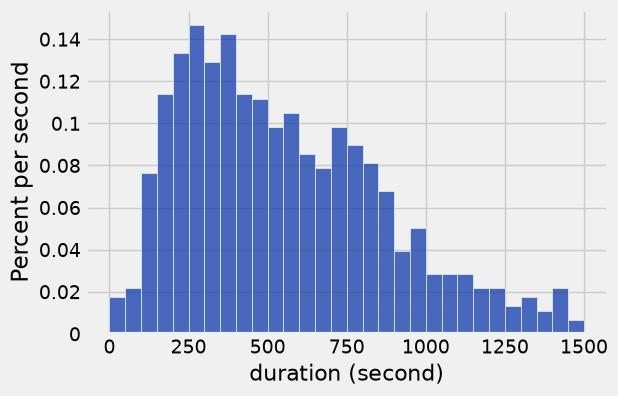

In [56]:
empirical_hist_duration(1000)

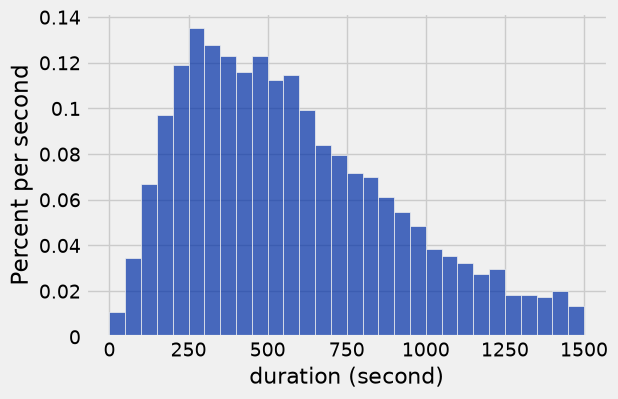

In [59]:
empirical_hist_duration(10000)

# Empirical distribution of a statistic

In [60]:
np.median(trips.column('duration'))  # this the true value of the *parameter*

554.89300000000003

In [63]:
np.median(trips.sample(1000).column('duration'))

560.99000000000001

In [64]:
def random_sample_median():
    return np.median(trips.sample(1000).column('duration'))

medians = make_array()

for i in np.arange(5000):
    medians = np.append(medians, random_sample_median())

In [65]:
medians

array([ 547.5145,  540.773 ,  558.6695, ...,  564.242 ,  564.253 ,
        554.659 ])

In [66]:
simulated_medians = Table().with_column('Sample Median', medians)
simulated_medians

Sample Median
547.514
540.773
558.669
521.188
580.421
556.088
560.121
552.987
589.072
567.693


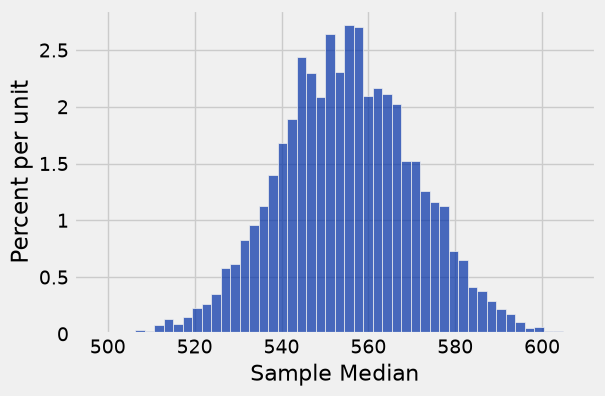

In [67]:
simulated_medians.hist(0, bins=50)

In [68]:
temps = Table.read_table('data/max-min-temperatures-fresno-up-to-2025.csv')
temps

Date,Highest High,Highest High Year,Lowest Low,Lowest Low Year
01/01,69,1998,21,1976
01/02,70,1948,20,1976
01/03,72,1948,23,1976
01/04,71,1948,22,1976
01/05,72,2018,20,1949
01/06,73,1948,17,1913
01/07,71,1911,20,1913
01/08,72,1911,22,1888
01/09,70,1953,23,1949
01/10,68,2025,18,1949


In [69]:
def random_sample_average():
    return np.average(temps.sample(100).column('Highest High'))

averages = make_array()

for i in np.arange(10000):
    averages = np.append(averages, random_sample_average())

In [71]:
averages

array([ 93.67,  94.29,  94.64, ...,  94.29,  94.72,  94.11])

In [72]:
np.average(temps.column('Highest High'))

93.469945355191257

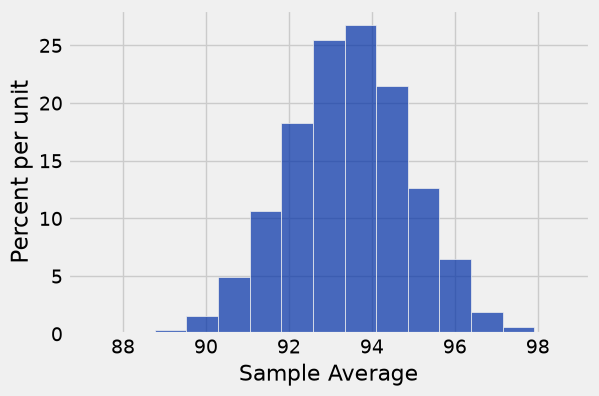

In [74]:
Table().with_column('Sample Average', averages).hist(0, bins=15)

# sample_proportions

In [75]:
# the following process is tedious
coin = Table().with_column('Face', make_array('Heads', 'Tails'))
coin

Face
Heads
Tails


In [79]:
coin.sample(100).group('Face').column('count') / 100

array([ 0.52,  0.48])

In [90]:
distribution = make_array(0.5, 0.5) # [0.5, 0.5] would work here too
sample_proportions(100, distribution)

array([ 0.51,  0.49])

In [99]:
sample_proportions(1000, distribution)

array([ 0.497,  0.503])